<a href="https://colab.research.google.com/github/jpechico/conda/blob/main/1_WaPOR_download_colab/Download_WaPORv3_Data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Download WaPOR version 3 Data.

[![](https://raw.githubusercontent.com//wateraccounting/WaPORMOOC/main/images/colab-badge.png)](https://colab.research.google.com/github/wateraccounting/WaPORMOOC/blob/main/1_WaPOR_download_colab/Download_WaPORv3_Data.ipynb?target="_blank")

To run the Notebook in Colab click [here](https://colab.research.google.com/github/wateraccounting/WaPORMOOC/blob/main/1_WaPOR_download_colab/Download_WaPORv3_Data.ipynb?target="_blank")

---


In this notebook we will use the [wapordl package](https://bitbucket.org/cioapps/wapordl/src/main/) made available by FAO to download WaPOR v3 data and download files to your local computer. This short [video](https://www.youtube.com/watch?v=ymBM_EVPEMQ) explains how to use this script. For details of how to use the downloaded WaPOR v3 data, refer to the [MOOC on Introduction to WaPORv3](https://ocw.un-ihe.org/course/view.php?id=263).

   
The steps are:

0. Install and load necessary packages
1. Upload a geojson file to define the boundary of area of interest
2. Use the wapordl package to download raster files for each variable
3. Zip the rasters files and download them to local folder

This script can be used without [mounting](https://colab.research.google.com/notebooks/snippets/drive.ipynb) Google colab with your Google Drive, if you want to use files stored in your Google Drive or save the files there, you have to mount the script first.

**NOTE**: This script allows for downloading WaPOR data in separate tiffs using the WaPOR naming convention, removal of the scaling factor and creating data in the units per the temporal scale of the data (eg dekadal data is converted from mm/day to mm/dekade). For more information about WaPOR data formats check out this [video](https://www.youtube.com/watch?v=nm5IAy4MHg4). Removal of the scaling factor increases the file size, for more advanced users, check out the [wapordl package](https://bitbucket.org/cioapps/wapordl/src/main/) created by FAO for more ways to download WaPORv3 data (including an option for downloading 1 file with scaled values in multiple bands for saving space, do note to make sure the scaling factor is applied when utilising such data).

 © 2024 IHE Delft Licenced under CC BY SA Creative Commons

---

## **Step 0 - Install and load necessary packages**
As a check we also report the wapordl version you are using (to use to report an issue)

In [1]:
%%capture
!pip install --upgrade wapordl --quiet


In [2]:
import wapordl
print(wapordl.__version__)

INFO: WaPORDL (`1.2.1`)


1.2.1


#### Import and load required packages

In [3]:
# from osgeo import gdal
import glob
import os
from wapordl import wapor_map
from wapordl import wapor_ts



---



## **Step 1 - Upload a geojson file to define the boundary of area of interest**
Area of interest can be defined either by providing a geojson file or by bounding box (coordinates of the extent of the area of interest). In this step you can upload your geojson file. If you decide to use the bounding box approach you can skip this step.

*NOTE*: wapordl only support geojson file format at the moment. If you have a file in other format, you can use QGIS to export it as geojson.



In [4]:
#To upload file.
from google.colab import files
uploaded = files.upload()

Saving ChkPA.geojson to ChkPA.geojson


If the script doesnt run, please check if the geojson is in 2D format. (Shapely does currently not support 3D geometries, so the workaround is to [convert your 3D geometries to 2D](https://gis.stackexchange.com/questions/255540/convert-3d-shapefile-to-2d-in-qgis)). For more advanced users you can also link the script to a file stored in your google drive, but then you have to mount your script first.



---



## **Step 2 - Use the wapordl package to download raster files for each variable**

To use the wapordl package to download WaPOR data, you need to 1) define the area of interest (either in geojson file or bounding box defined as [xmin, ymin, xmax, ymax]), 2) the variables to download and the time period, and 3) the folder where to save the downloaded files.

The variables which can be downloaded include AETI (actual evapotranspiration and interception), T (transpiration), I (interception), E (evaporation), NPP (Net Primary Product), PCP (Precipitation), RET (Reference Evapotranspiration) and RSM (Relative Soil Moisture). There are 3 levels of WaPOR data (L1, L2 and L3) related to the resolution of the data and in terms of temporal resolution, Daily (E), Dekadal (D), Monthly (M) and Annual (A). Check in the [WaPOR portal](https://data.apps.fao.org/wapor/?lang=en) in which temporal resolution the data you want to download is available.

Refer to the **[WaPOR overview](https://www.fao.org/in-action/remote-sensing-for-water-productivity/wapor-data/en)** to read more about the WaPOR data, its spatial and temporal coverage and the contents of the database. For the WaPOR variables naming convention, see the image below.

![](https://raw.githubusercontent.com/wateraccounting/WaPORMOOC/main/images/WaPOR%20naming%20conventions_update.jpg)

In [14]:
# 1) define region (remove comment (#) for the option you plan to use)
# define region using geojson file (if using a file stored in your google drive, add relative path here)
region = r"/content/ChkPA.geojson"

# define region in bounding box
# region = [39.17, 8.32, 39.37, 8.50] # [xmin, ymin, xmax, ymax]

# 2) define the variables and timeperiod to download
variables = ["L3-NPP-M"] #, "L3-NPP","L3-NPP-M"]
period = ["2018-01-01", "2023-12-31"]
overview = "NONE"

for var in variables:

  # 3) Define a folder to save the downloaded rasters (this will create a temporary folder
  # called output, if you want the data to be stored somewhere else change the
  # path, this requires mounting of the colab script)
  folder = r"/content/output"+f"/{var}"
  if not os.path.exists(folder):
          os.makedirs(folder)

  if('-E' in var):
    unit = "day"
  elif('-D' in var):
    unit = "dekad"
  elif('-M' in var):
    unit = "month"
  elif ('-A' in var):
    unit = "year"
  else:
    unit = "none"

  fps = wapor_map(region, var, period, folder, separate_unscale = True, unit_conversion = unit)

INFO: Given `region` matches with `MBL` L3 region.
INFO: Found 72 files for L3-NPP-M.
INFO: Units are already as requested, no conversion needed.
INFO: Splitting single GeoTIFF into multiple unscaled files.


The raster files can be found in the output folder, which can be manually downloaded. Alternatively go to step 3 to use a script for downloading.  

---



## **Step 3 - Zip the raster files and download them to local folder**

This script will zip the contents of the output folder and download the zipped file to our local computer by running the following cell.

*NOTE*: update the extensions if you have changed the output file location.

In [7]:
!zip -r /content/data.zip /content/output
from google.colab import files
files.download(r'/content/data.zip')


  adding: content/output/ (stored 0%)
  adding: content/output/L3-AETI-M/ (stored 0%)
  adding: content/output/L3-AETI-M/ChkPA.MBL_L3-AETI-M_NONE_month_2020-08-01.tif (deflated 36%)
  adding: content/output/L3-AETI-M/ChkPA.MBL_L3-AETI-M_NONE_month_2020-09-01.tif (deflated 42%)
  adding: content/output/L3-AETI-M/ChkPA.MBL_L3-AETI-M_NONE_month_2021-09-01.tif (deflated 42%)
  adding: content/output/L3-AETI-M/ChkPA.MBL_L3-AETI-M_NONE_month_2021-12-01.tif (deflated 34%)
  adding: content/output/L3-AETI-M/ChkPA.MBL_L3-AETI-M_NONE_month_2023-03-01.tif (deflated 34%)
  adding: content/output/L3-AETI-M/ChkPA.MBL_L3-AETI-M_NONE_month_2019-10-01.tif (deflated 35%)
  adding: content/output/L3-AETI-M/ChkPA.MBL_L3-AETI-M_NONE_month_2023-12-01.tif (deflated 33%)
  adding: content/output/L3-AETI-M/ChkPA.MBL_L3-AETI-M_NONE_month_2019-03-01.tif (deflated 33%)
  adding: content/output/L3-AETI-M/ChkPA.MBL_L3-AETI-M_NONE_month_2021-10-01.tif (deflated 35%)
  adding: content/output/L3-AETI-M/ChkPA.MBL_L3-AE

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Visualizing: /content/output/L3-NPP-M/ChkPA.MBL_L3-NPP-M_NONE_month_2018-03-01.tif


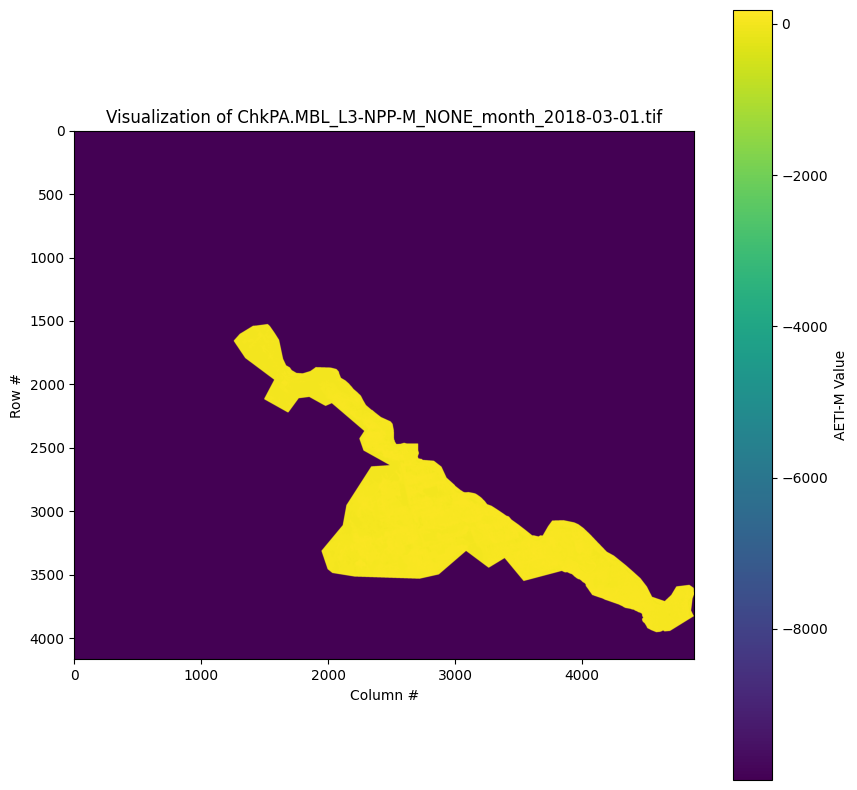

In [18]:
import rasterio
import matplotlib.pyplot as plt

# Get the path to the first downloaded GeoTIFF file
# The 'fps' variable contains a list of all downloaded file paths.
if fps:
    first_geotiff_path = fps[2]
    print(f"Visualizing: {first_geotiff_path}")

    # Open the GeoTIFF file with rasterio
    with rasterio.open(first_geotiff_path) as src:
        # Read the first band of the raster data
        data = src.read(1) # Changed from 2 to 1

        # Plot the data
        plt.figure(figsize=(10, 10))
        plt.imshow(data, cmap='viridis')
        plt.colorbar(label='AETI-M Value')
        plt.title(f'Visualization of {os.path.basename(first_geotiff_path)}')
        plt.xlabel('Column #')
        plt.ylabel('Row #')
        plt.show()
else:
    print("No GeoTIFF files found to visualize. Please ensure Step 2 was executed successfully.")

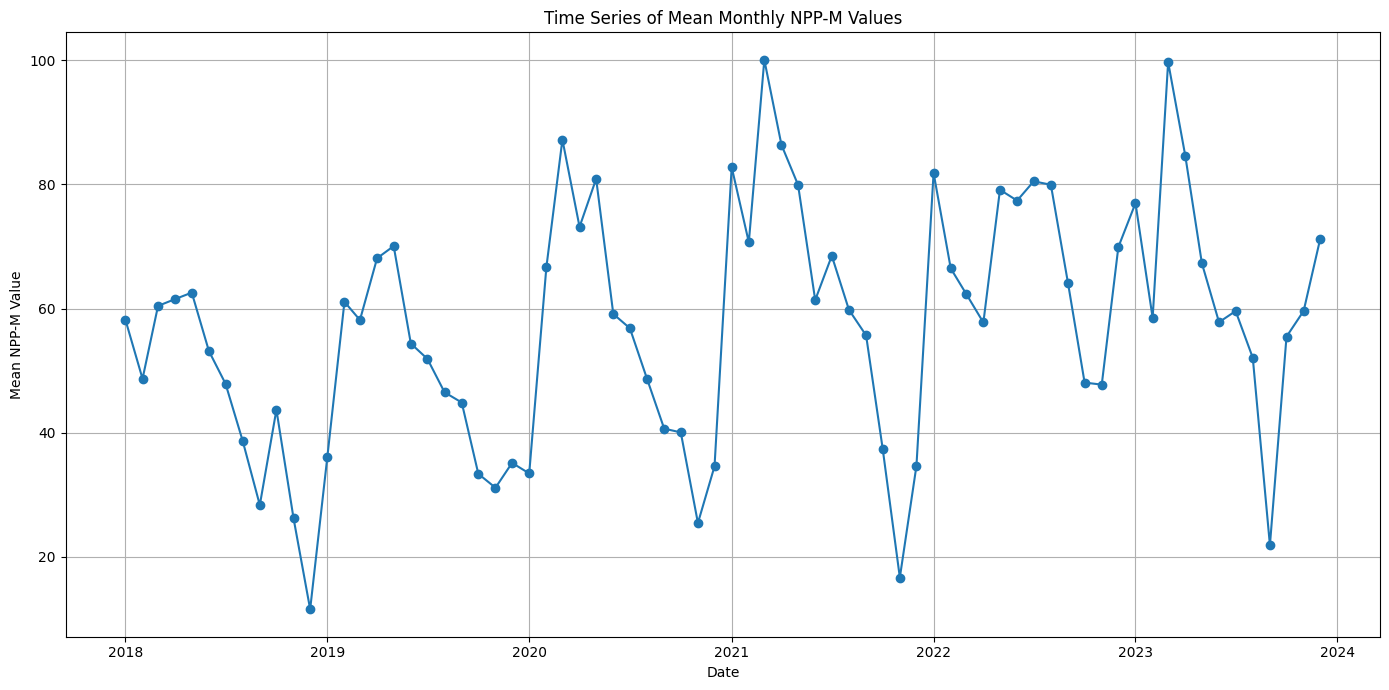

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import rasterio
import os
import numpy as np

# Initialize lists to store dates and AETI-M values
dates = []
aeti_values = []

# Assuming fps contains the list of file paths
if fps:
    for file_path in fps:
        # Extract date from filename
        # Example filename: ChkPA.MBL_L3-AETI-M_NONE_month_2018-01-01.tif
        file_name = os.path.basename(file_path)
        # The date is the last part of the filename, before the .tif extension
        date_str = file_name.split('_')[-1].replace('.tif', '')
        try:
            date = pd.to_datetime(date_str)
            dates.append(date)

            # Open the GeoTIFF file and read the data
            with rasterio.open(file_path) as src:
                data = src.read(1)
                # Replace nodata values (-9999.0) with NaN for correct mean calculation
                data[data == -9999.0] = np.nan
                # Calculate the mean of valid data points
                mean_aeti = np.nanmean(data)
                aeti_values.append(mean_aeti)
        except Exception as e:
            print(f"Could not process file {file_name}: {e}")

    # Create a pandas DataFrame
    df = pd.DataFrame({'Date': dates, 'NPP-M': aeti_values})
    df = df.sort_values(by='Date').reset_index(drop=True)

    # Plotting the time series
    plt.figure(figsize=(14, 7))
    plt.plot(df['Date'], df['NPP-M'], marker='o', linestyle='-')
    plt.title('Time Series of Mean Monthly NPP-M Values')
    plt.xlabel('Date')
    plt.ylabel('Mean NPP-M Value')
    plt.grid(True)
    plt.tight_layout()
    plt.show()
else:
    print("No GeoTIFF files found in 'fps' to plot time series.")

In [17]:
# Save the DataFrame to a CSV file
df.to_csv('/content/processed_data.csv', index=False)
print("DataFrame saved to /content/processed_data.csv")

DataFrame saved to /content/processed_data.csv


In [ ]:
# # if you want to delete a folder use the code below.
# !rm -rf /content/output
# !rm -rf /content/tifs
# !rm -rf /content/data.zip